# 03 — Linear Transformations & Systems of Linear Equations

A matrix isn't just a grid of numbers — it represents a **function** that
maps vectors to other vectors. This notebook visualizes that idea, and
uses the from-scratch Gaussian elimination solver
(`matrix_operations.solve_linear_system`) to solve `Ax = b`.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
np.set_printoptions(precision=4, suppress=True)

import matplotlib.pyplot as plt

## A matrix as a geometric transformation

Applying a matrix to every point of a shape transforms that shape. Below,
a square is transformed by a scaling + shearing matrix.

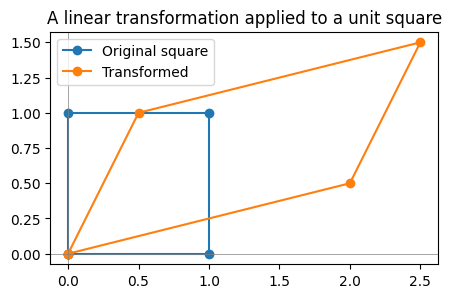

In [2]:
from matrix_operations import apply_linear_transformation

# Unit square corners
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])

A = np.array([[2, 0.5],
              [0.5, 1]])

transformed = np.array([apply_linear_transformation(A, point) for point in square])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(square[:, 0], square[:, 1], "o-", label="Original square")
ax.plot(transformed[:, 0], transformed[:, 1], "o-", label="Transformed")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_aspect("equal")
ax.legend()
ax.set_title("A linear transformation applied to a unit square")
plt.show()

## Eigenvector intuition (preview)

Most directions get rotated *and* scaled by a transformation. A special
few directions — the matrix's **eigenvectors** — only get scaled, not
rotated. We'll compute these properly in notebook 04; here's a quick
visual preview using two candidate directions.

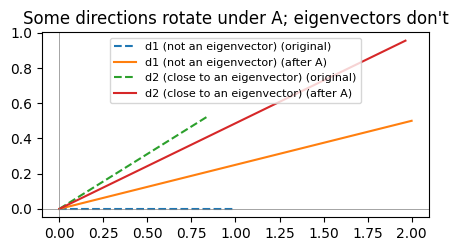

In [3]:
directions = {"d1 (not an eigenvector)": np.array([1, 0]),
              "d2 (close to an eigenvector)": np.array([0.85, 0.53])}

fig, ax = plt.subplots(figsize=(5, 5))
for label, d in directions.items():
    Ad = apply_linear_transformation(A, d)
    ax.plot([0, d[0]], [0, d[1]], "--", label=f"{label} (original)")
    ax.plot([0, Ad[0]], [0, Ad[1]], "-", label=f"{label} (after A)")

ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_aspect("equal")
ax.legend(fontsize=8)
ax.set_title("Some directions rotate under A; eigenvectors don't")
plt.show()

## Solving a system of linear equations

Given $Ax = b$, we solve for $x$ using Gaussian elimination with partial
pivoting (implemented from scratch in `matrix_operations.solve_linear_system`).

In [4]:
from matrix_operations import solve_linear_system

A_sys = np.array([[2, 1, -1],
                   [-3, -1, 2],
                   [-2, 1, 2]])
b_sys = np.array([8, -11, -3])

x_mine = solve_linear_system(A_sys, b_sys)
x_numpy = np.linalg.solve(A_sys, b_sys)

print("x (mine) :", x_mine)
print("x (numpy):", x_numpy)

x (mine) : [ 2.  3. -1.]
x (numpy): [ 2.  3. -1.]


## Why this matters for ML

- Linear layers in neural networks *are* linear transformations.
- Linear regression's closed-form solution requires solving a linear
  system (the normal equations).
- Understanding eigenvectors geometrically — directions a transformation
  doesn't rotate — is exactly the intuition PCA relies on, which we build
  next.